<a href="https://colab.research.google.com/github/Ermek-A/Kyrgyzstan_data/blob/main/kyrgyzstan_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🇰🇬 Kyrgyzstan Applied Statistics Project
### Descriptive Statistics · Correlation · Regression · Hypothesis Testing
###Name:Ermek group:Matdais24
---

| | |
|---|---|
| **Dataset** | World Bank Open Data — Kyrgyz Republic |
| **Period** | 2000–2023 |
| **Indicators** | 17 socio-economic indicators |
| **Tools** | Python · Pandas · SciPy · Matplotlib · Seaborn |

---

## Project Overview

This notebook applies **formal statistical methods** to analyze socio-economic data for the Kyrgyz Republic. We move beyond description to test hypotheses, quantify relationships, and build a predictive model — all grounded in statistical theory.

### Project Structure
| Section | Method | Requirement |
|---------|--------|-------------|
| 1. Data Loading | Clean shared dataset | — |
| 2. Descriptive Statistics | Summary table, distributions | Summary table |
| 3. Visualization | 6 statistical charts | ≥2 visualizations |
| 4. Correlation Analysis | Pearson r, significance testing | Correlation analysis |
| 5. Regression Analysis | OLS linear regression | Regression analysis |
| 6. Hypothesis Testing | Two-sample t-test, one-way ANOVA | Categorical/hypothesis test |
| 7. Conclusions | Written interpretation | Full sentences |
| 8. Limitations | Explicit notes | Limitation note |

### Central Statistical Questions
1. What is the statistical relationship between GDP and quality-of-life indicators?
2. Can economic growth predict life expectancy?
3. Did Kyrgyzstan's GDP per capita significantly change across historical eras?

---
## 1. Data Loading & Cleaning

We use the same World Bank dataset as the Data Wrangling project. The cleaning pipeline is reproduced here for notebook independence.

In [ ]:
# ── Import libraries ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, shapiro, levene
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(' Libraries loaded')

 Libraries loaded


In [ ]:
# ── Load and clean data ───────────────────────────────────────────────────
df_raw = pd.read_csv('API_KGZ_DS2_en_csv_v2_15245.csv', skiprows=4)
df_raw.columns = df_raw.columns.str.strip().str.lower().str.replace(' ', '_')
df_raw = df_raw.drop_duplicates()

indicators = [
    'GDP (current US$)', 'GDP growth (annual %)', 'GDP per capita (current US$)',
    'Population, total', 'Population growth (annual %)',
    'Inflation, consumer prices (annual %)',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)',
    'Life expectancy at birth, total (years)',
    'Mortality rate, infant (per 1,000 live births)',
    'Literacy rate, adult total (% of people ages 15 and above)',
    'School enrollment, primary (% gross)',
    'Government expenditure on education, total (% of GDP)',
    'Poverty headcount ratio at national poverty lines (% of population)',
    'Gini index', 'Personal remittances, received (% of GDP)',
    'Access to electricity (% of population)',
    'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)',
]

df_f = df_raw[df_raw['indicator_name'].isin(indicators)].copy()
year_cols = [str(y) for y in range(2000, 2024)]
df_long = df_f.melt(id_vars=['indicator_name'], value_vars=year_cols,
                     var_name='year', value_name='value')
df_long['year'] = df_long['year'].astype(int)

df = df_long.pivot_table(index='year', columns='indicator_name', values='value').reset_index()
df.columns.name = None
df = df.rename(columns={
    'GDP (current US$)': 'gdp', 'GDP growth (annual %)': 'gdp_growth',
    'GDP per capita (current US$)': 'gdp_per_capita', 'Population, total': 'population',
    'Population growth (annual %)': 'pop_growth',
    'Inflation, consumer prices (annual %)': 'inflation',
    'Unemployment, total (% of total labor force) (modeled ILO estimate)': 'unemployment',
    'Life expectancy at birth, total (years)': 'life_expectancy',
    'Mortality rate, infant (per 1,000 live births)': 'infant_mortality',
    'Literacy rate, adult total (% of people ages 15 and above)': 'literacy_rate',
    'School enrollment, primary (% gross)': 'school_enrollment',
    'Government expenditure on education, total (% of GDP)': 'edu_expenditure',
    'Poverty headcount ratio at national poverty lines (% of population)': 'poverty_rate',
    'Gini index': 'gini', 'Personal remittances, received (% of GDP)': 'remittances',
    'Access to electricity (% of population)': 'electricity_access',
    'PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)': 'pm25',
})

# Interpolate missing values
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].interpolate(method='linear', limit_direction='both')

# Add era categorical variable
df['era'] = pd.cut(df['year'], bins=[1999, 2009, 2015, 2023],
                   labels=['2000s', '2010–2015', '2016–2023'])

print(f' Dataset ready: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(3)

 Dataset ready: 24 rows × 19 columns


,year,electricity_access,gdp,gdp_growth,gdp_per_capita,gini,edu_expenditure,inflation,life_expectancy,literacy_rate,infant_mortality,pm25,remittances,pop_growth,population,poverty_rate,school_enrollment,unemployment,era
0,2000,99.6,1.369688e+09,5.443337,279.621738,31.0,3.50839,18.700734,68.558537,99.239998,44.0,23.038026,0.163812,1.189896,4898362.0,29.8,94.701859,2.143,2000s
1,2001,99.5,1.525116e+09,5.321621,308.411296,30.2,3.85418,6.919680,68.707317,99.239998,41.6,22.942916,0.297284,0.949086,4945073.0,29.8,93.927078,2.273,2000s
2,2002,100.0,1.605643e+09,-0.017325,321.726775,30.3,4.44546,2.134210,68.156098,99.239998,39.4,22.758294,1.886671,0.918525,4990704.0,29.8,93.423080,2.416,2000s


---
## 2. Descriptive Statistics

Descriptive statistics summarize the **central tendency** (mean, median) and **spread** (std, min, max) of each variable. The **Coefficient of Variation (CV%)** measures relative variability — high CV means a variable changed a lot over the study period.

In [ ]:
# ── Descriptive summary table ─────────────────────────────────────────────
key_cols = ['gdp_per_capita', 'gdp_growth', 'inflation', 'unemployment',
            'life_expectancy', 'infant_mortality', 'remittances', 'pm25', 'gini']

summary = df[key_cols].describe().T
summary['median']  = df[key_cols].median()
summary['skew']    = df[key_cols].skew().round(2)
summary['CV_%']    = (summary['std'] / summary['mean'] * 100).round(1)
summary = summary[['count','mean','median','std','min','max','skew','CV_%']]

summary.index = [
    'GDP per Capita (USD)', 'GDP Growth (%)', 'Inflation (%)',
    'Unemployment (%)', 'Life Expectancy (yrs)', 'Infant Mortality (per 1k)',
    'Remittances (% GDP)', 'PM2.5 (µg/m³)', 'Gini Index'
]

print('=' * 80)
print('DESCRIPTIVE SUMMARY TABLE — Kyrgyzstan 2000–2023')
print('=' * 80)
print(summary.round(2).to_string())
print('\nNote: CV% = Coefficient of Variation (std/mean × 100). Higher = more variable over time.')

DESCRIPTIVE SUMMARY TABLE — Kyrgyzstan 2000–2023
                           count    mean   median     std     min      max  skew  CV_%
GDP per Capita (USD)        24.0  983.00  1104.46  479.16  279.62  2138.22  0.28  48.7
GDP Growth (%)              24.0    4.40     4.67    3.96   -7.15    10.92 -0.98  89.9
Inflation (%)               24.0    7.65     6.56    5.98    0.39    24.52  1.28  78.3
Unemployment (%)            24.0    3.69     3.57    1.02    2.14     5.94  0.46  27.6
Life Expectancy (yrs)       24.0   69.84    69.80    1.54   67.70    72.25  0.13   2.2
Infant Mortality (per 1k)   24.0   25.62    23.25    9.31   15.00    44.00  0.53  36.4
Remittances (% GDP)         24.0   21.59    26.49   11.15    0.16    32.56 -0.95  51.6
PM2.5 (µg/m³)               24.0   26.13    24.38    3.82   22.42    34.38  1.04  14.6
Gini Index                  24.0   29.71    29.00    2.75   26.40    37.40  1.25   9.2

Note: CV% = Coefficient of Variation (std/mean × 100). Higher = more variable ov

In [ ]:
summary_rounded = summary.round(2)

# создаем фигуру
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# создаем таблицу
table = ax.table(
    cellText=summary_rounded.values,
    colLabels=summary_rounded.columns,
    rowLabels=summary_rounded.index,
    loc='center'
)

# делаем читаемее
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# заголовок
plt.title('Descriptive Summary — Kyrgyzstan (2000–2023)', fontsize=14)

# сохраняем
plt.savefig('summary_table.png', bbox_inches='tight', dpi=300)
plt.close()

**Interpretation of the descriptive table:**

- **GDP per capita** has the highest CV% (~49%), confirming strong economic growth but high variability across 23 years. The mean of $983 is well below the median of $1,104, suggesting left skew from low early-2000s values.
- **Infant mortality** (CV = 36%) shows dramatic improvement, falling from 44 to 15 per 1,000 births — a public health success.
- **Inflation** (CV = ~70%) is the most volatile economic indicator, with values ranging from 0.4% to 24.5% — reflecting monetary instability in transition years.
- **Gini index** has the lowest CV% (9.2%), meaning income inequality was relatively stable across the period, hovering around 29–30.

---
## 3. Visualizations

We use six chart types to explore distributions, trends, and relationships statistically.

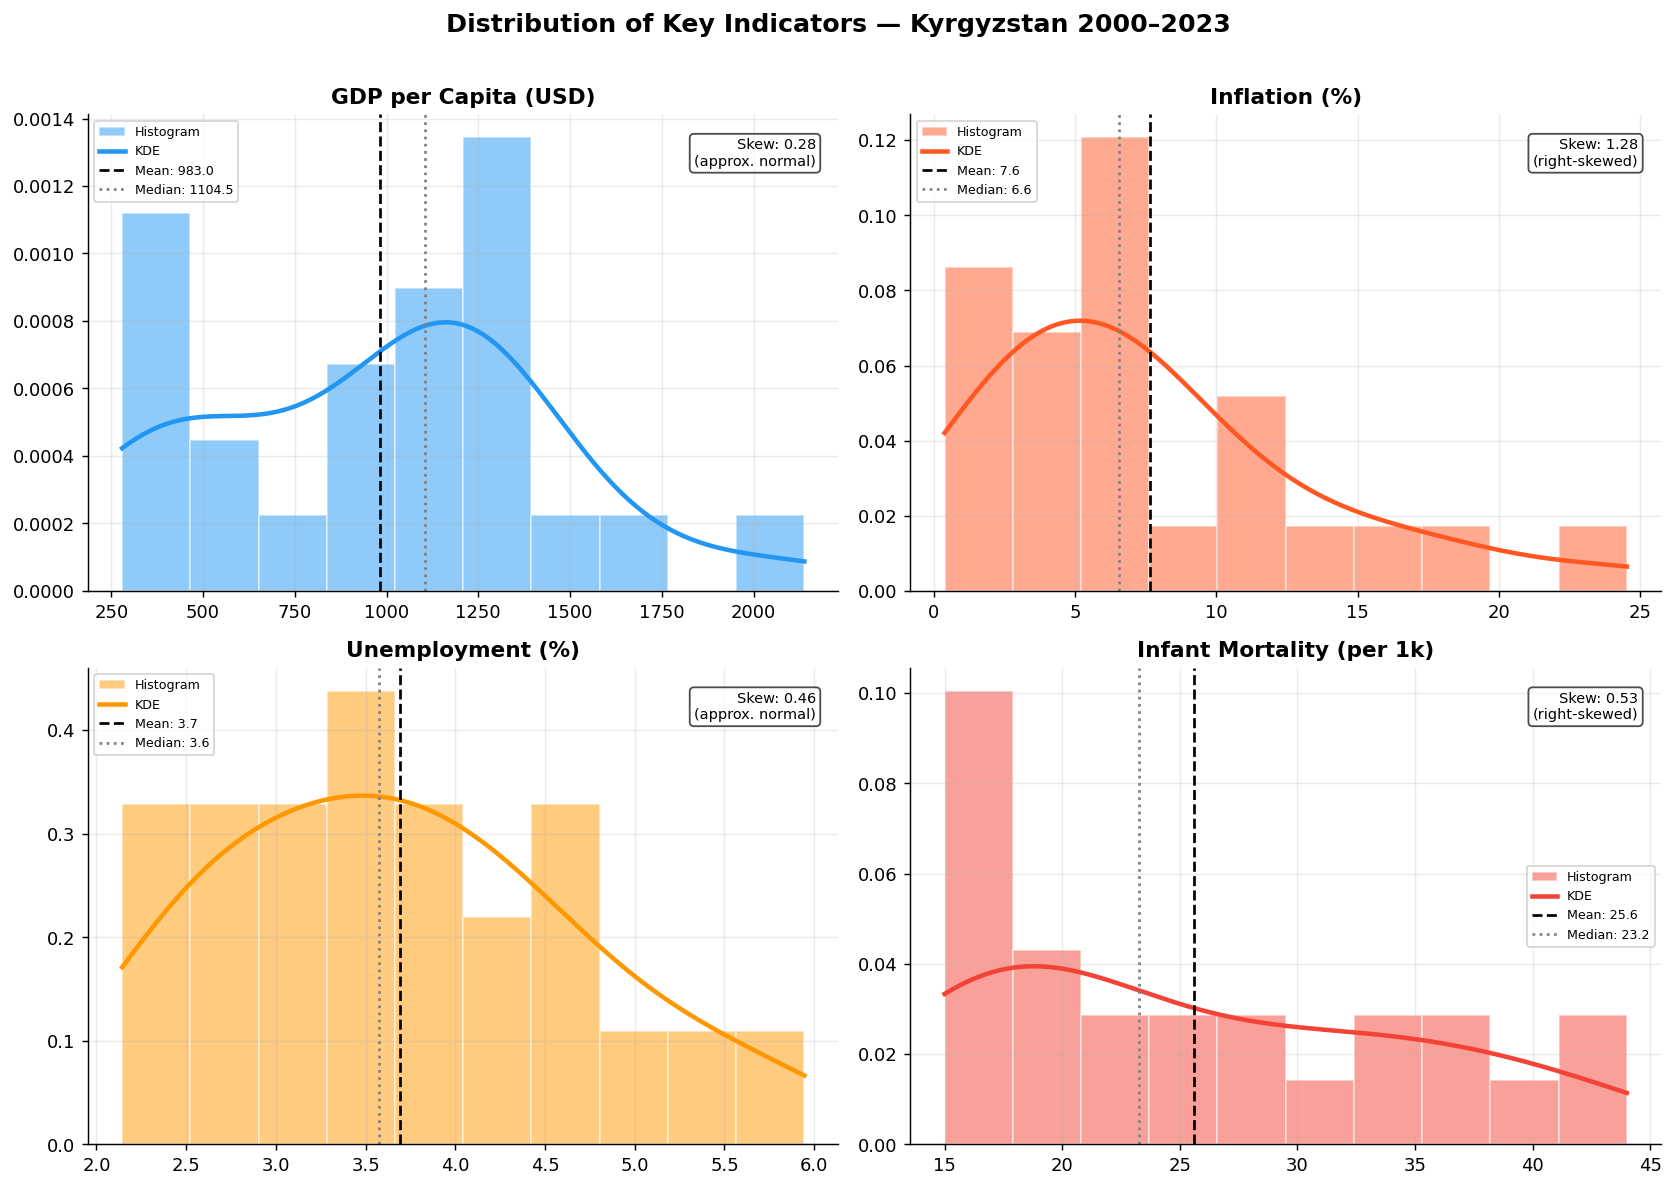

In [ ]:
# ── Visualization 1: Distribution plots (histograms + KDE) ───────────────
# Shows the shape of each variable's distribution

dist_cols = ['gdp_per_capita', 'inflation', 'unemployment', 'infant_mortality']
dist_labels = ['GDP per Capita (USD)', 'Inflation (%)', 'Unemployment (%)', 'Infant Mortality (per 1k)']
colors = ['#2196F3', '#FF5722', '#FF9800', '#F44336']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Distribution of Key Indicators — Kyrgyzstan 2000–2023',
             fontsize=14, fontweight='bold', y=1.01)

for ax, col, label, color in zip(axes.flat, dist_cols, dist_labels, colors):
    data = df[col].dropna()
    ax.hist(data, bins=10, color=color, alpha=0.5, edgecolor='white', density=True, label='Histogram')

    # KDE curve
    kde_x = np.linspace(data.min(), data.max(), 200)
    kde = stats.gaussian_kde(data)
    ax.plot(kde_x, kde(kde_x), color=color, linewidth=2.5, label='KDE')

    # Mean and median lines
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='gray',  linestyle=':',  linewidth=1.5, label=f'Median: {data.median():.1f}')

    # Skewness annotation
    skew_val = data.skew()
    skew_dir = 'right-skewed' if skew_val > 0.5 else ('left-skewed' if skew_val < -0.5 else 'approx. normal')
    ax.text(0.97, 0.95, f'Skew: {skew_val:.2f}\n({skew_dir})',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=7); ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig('stats_viz1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

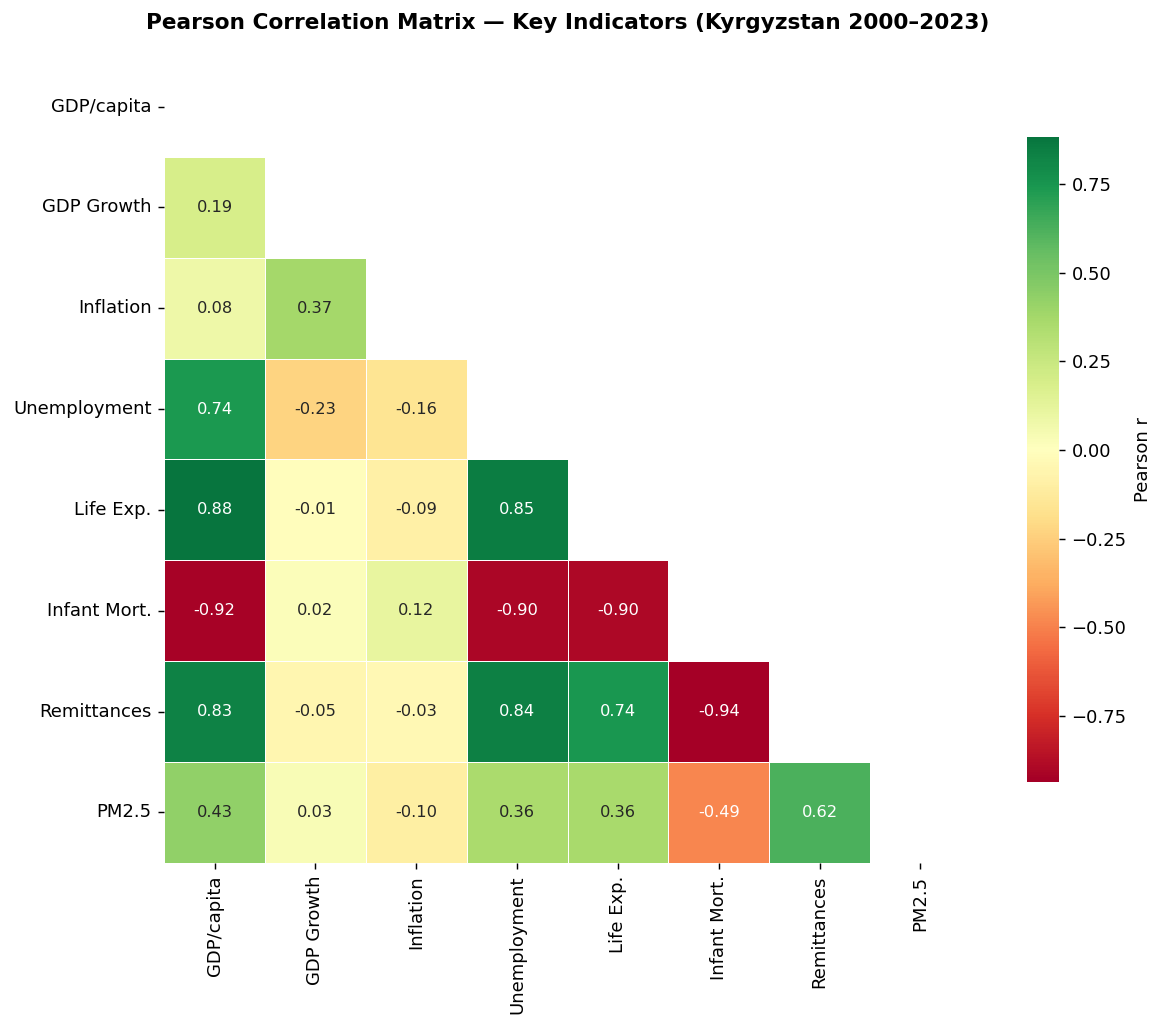

In [ ]:
# ── Visualization 2: Correlation heatmap ─────────────────────────────────
corr_cols   = ['gdp_per_capita','gdp_growth','inflation','unemployment',
               'life_expectancy','infant_mortality','remittances','pm25']
corr_labels = ['GDP/capita','GDP Growth','Inflation','Unemployment',
               'Life Exp.','Infant Mort.','Remittances','PM2.5']

corr = df[corr_cols].corr()
corr.index = corr_labels; corr.columns = corr_labels
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True,
            annot_kws={'size': 9}, cbar_kws={'label': 'Pearson r', 'shrink': 0.8})
ax.set_title('Pearson Correlation Matrix — Key Indicators (Kyrgyzstan 2000–2023)',
             fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('stats_viz2_correlation_heatmap.png', dpi=150)
plt.show()

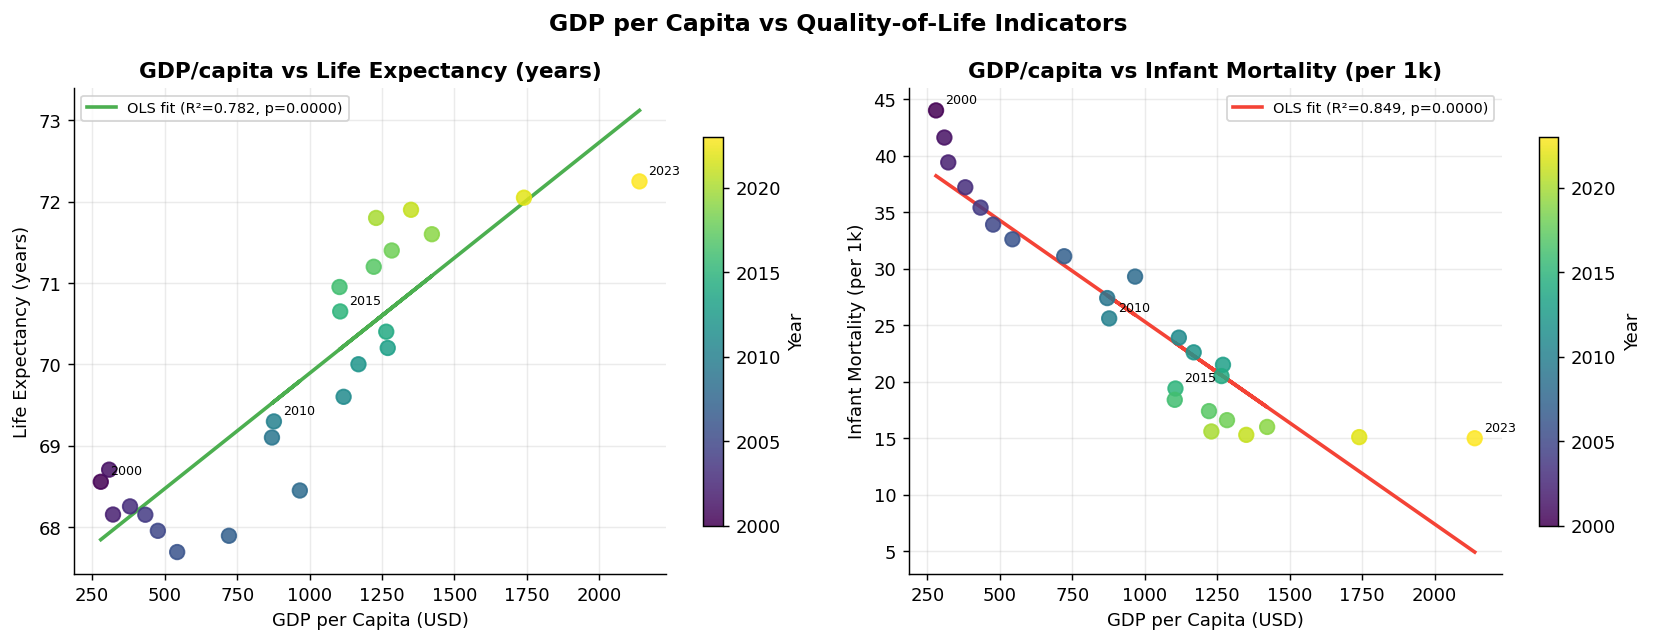

In [ ]:
# ── Visualization 3: Scatter plots — GDP vs quality-of-life ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('GDP per Capita vs Quality-of-Life Indicators', fontsize=13, fontweight='bold')

pairs = [
    ('gdp_per_capita', 'life_expectancy',  'Life Expectancy (years)',  '#4CAF50'),
    ('gdp_per_capita', 'infant_mortality', 'Infant Mortality (per 1k)', '#F44336'),
]

for ax, (xcol, ycol, ylabel, color) in zip(axes, pairs):
    x = df[xcol]; y = df[ycol]
    slope, intercept, r, p, se = stats.linregress(x, y)

    sc = ax.scatter(x, y, c=df['year'], cmap='viridis', s=65, alpha=0.85, zorder=3)
    ax.plot(x, slope*x + intercept, color=color, linewidth=2,
            label=f'OLS fit (R²={r**2:.3f}, p={p:.4f})')

    # Label key years
    for yr in [2000, 2010, 2015, 2023]:
        row = df[df['year']==yr]
        if len(row):
            ax.annotate(str(yr),
                        (row[xcol].values[0], row[ycol].values[0]),
                        textcoords='offset points', xytext=(5, 4), fontsize=7)

    plt.colorbar(sc, ax=ax, label='Year', shrink=0.8)
    ax.set_xlabel('GDP per Capita (USD)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(f'GDP/capita vs {ylabel}', fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('stats_viz3_scatter.png', dpi=150)
plt.show()

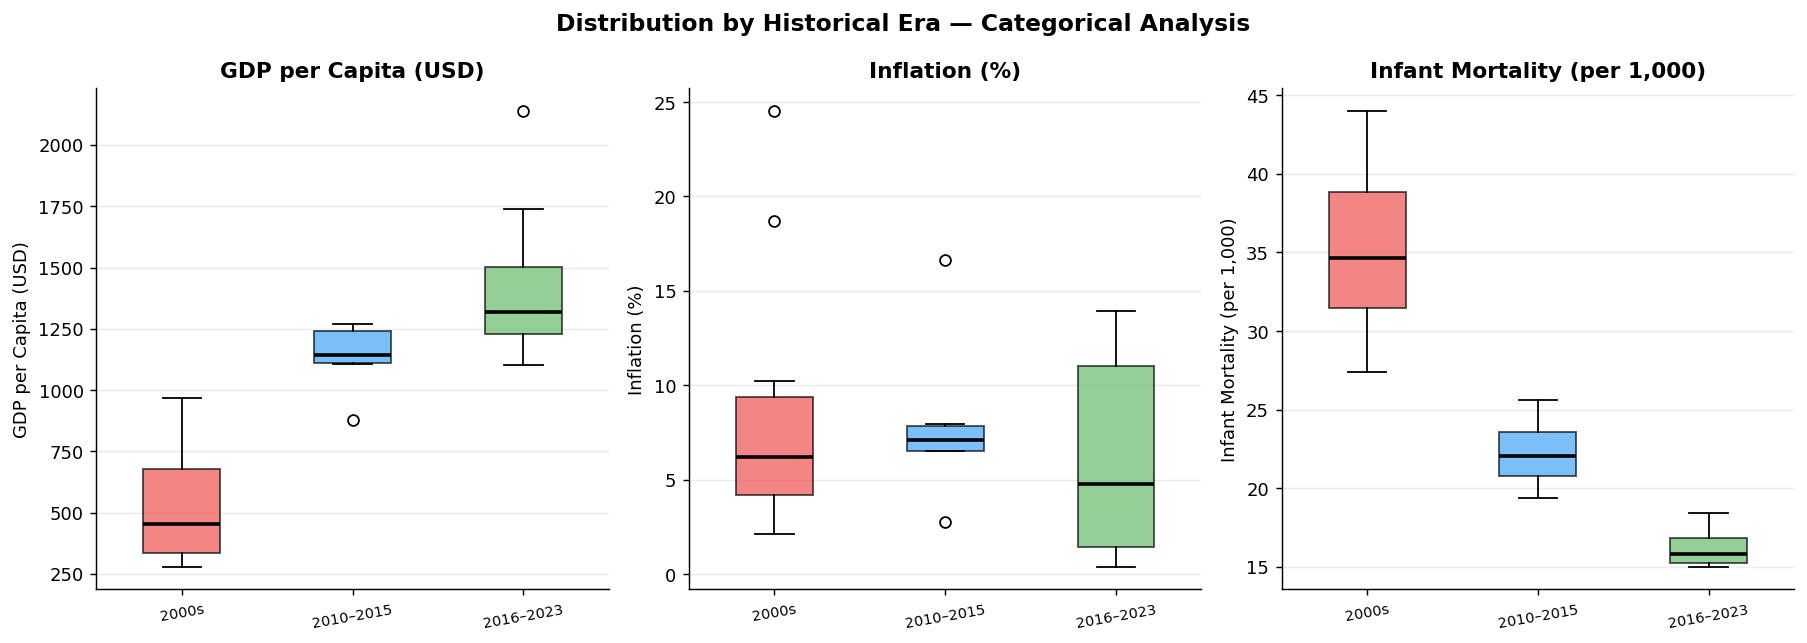

In [ ]:
# ── Visualization 4: Boxplots by era (categorical comparison) ────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Distribution by Historical Era — Categorical Analysis',
             fontsize=13, fontweight='bold')

box_vars = [
    ('gdp_per_capita',  'GDP per Capita (USD)',        '#2196F3'),
    ('inflation',       'Inflation (%)',                '#FF5722'),
    ('infant_mortality','Infant Mortality (per 1,000)', '#F44336'),
]

era_order = ['2000s', '2010–2015', '2016–2023']
era_colors = ['#EF5350', '#42A5F5', '#66BB6A']

for ax, (col, label, _) in zip(axes, box_vars):
    groups = [df[df['era'] == e][col].dropna().values for e in era_order]
    bp = ax.boxplot(groups, labels=era_order, patch_artist=True,
                    widths=0.45, notch=False)
    for patch, color in zip(bp['boxes'], era_colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    for median in bp['medians']:
        median.set_color('black'); median.set_linewidth(2)

    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    ax.set_xticklabels(era_order, rotation=10, fontsize=8)
    ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('stats_viz4_boxplots.png', dpi=150)
plt.show()

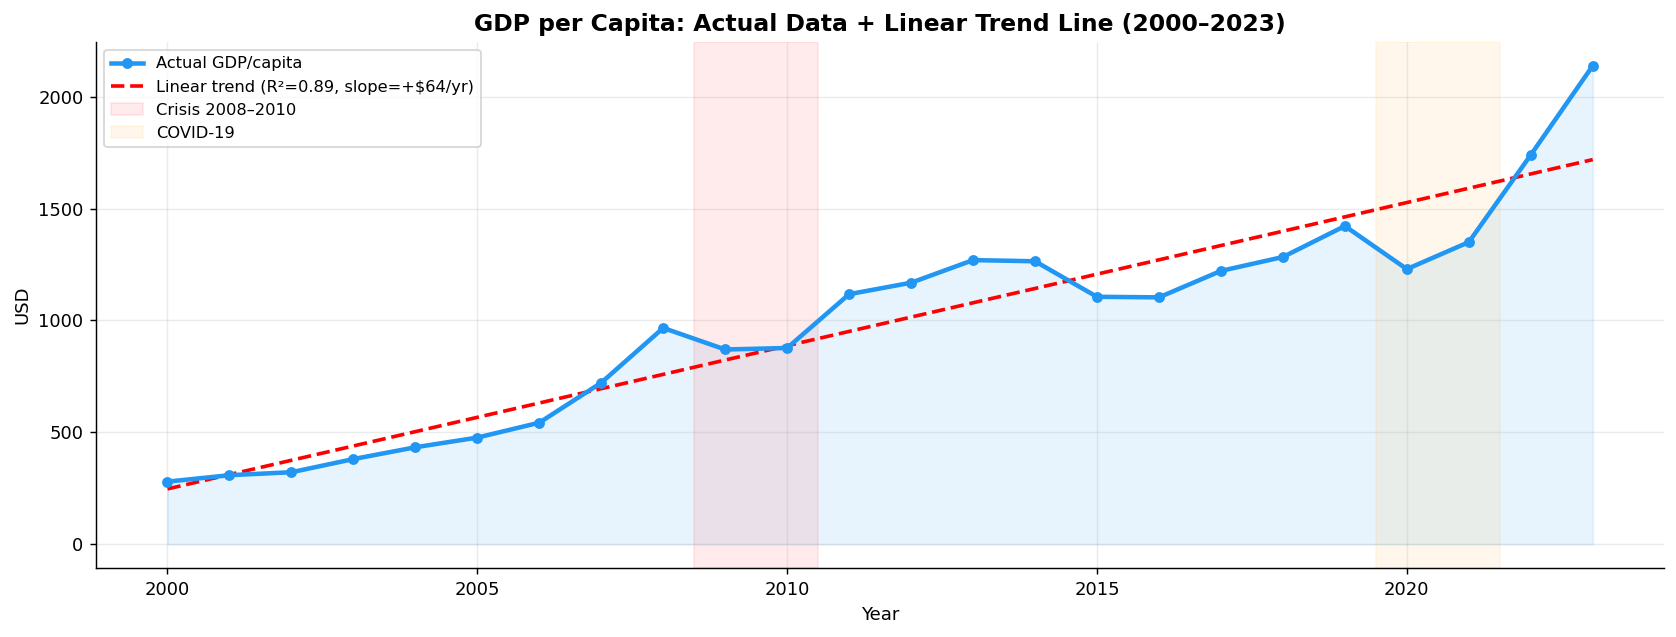


Linear time trend: GDP/capita increases by $64 per year on average.
R² = 0.892 — time alone explains 89.2% of GDP variation.


In [ ]:
# ── Visualization 5: Time series — GDP trend with regression line ─────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(df['year'], df['gdp_per_capita'], color='#2196F3',
        linewidth=2.5, marker='o', markersize=5, label='Actual GDP/capita', zorder=3)
ax.fill_between(df['year'], df['gdp_per_capita'], alpha=0.1, color='#2196F3')

# Add trend line (OLS on time)
slope_t, intercept_t, r_t, p_t, _ = stats.linregress(df['year'], df['gdp_per_capita'])
trend_y = slope_t * df['year'] + intercept_t
ax.plot(df['year'], trend_y, color='red', linewidth=2, linestyle='--',
        label=f'Linear trend (R²={r_t**2:.2f}, slope=+${slope_t:.0f}/yr)')

# Shade crisis periods
ax.axvspan(2008.5, 2010.5, alpha=0.08, color='red', label='Crisis 2008–2010')
ax.axvspan(2019.5, 2021.5, alpha=0.08, color='orange', label='COVID-19')

ax.set_title('GDP per Capita: Actual Data + Linear Trend Line (2000–2023)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('USD')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('stats_viz5_trend.png', dpi=150)
plt.show()

print(f'\nLinear time trend: GDP/capita increases by ${slope_t:.0f} per year on average.')
print(f'R² = {r_t**2:.3f} — time alone explains {r_t**2*100:.1f}% of GDP variation.')

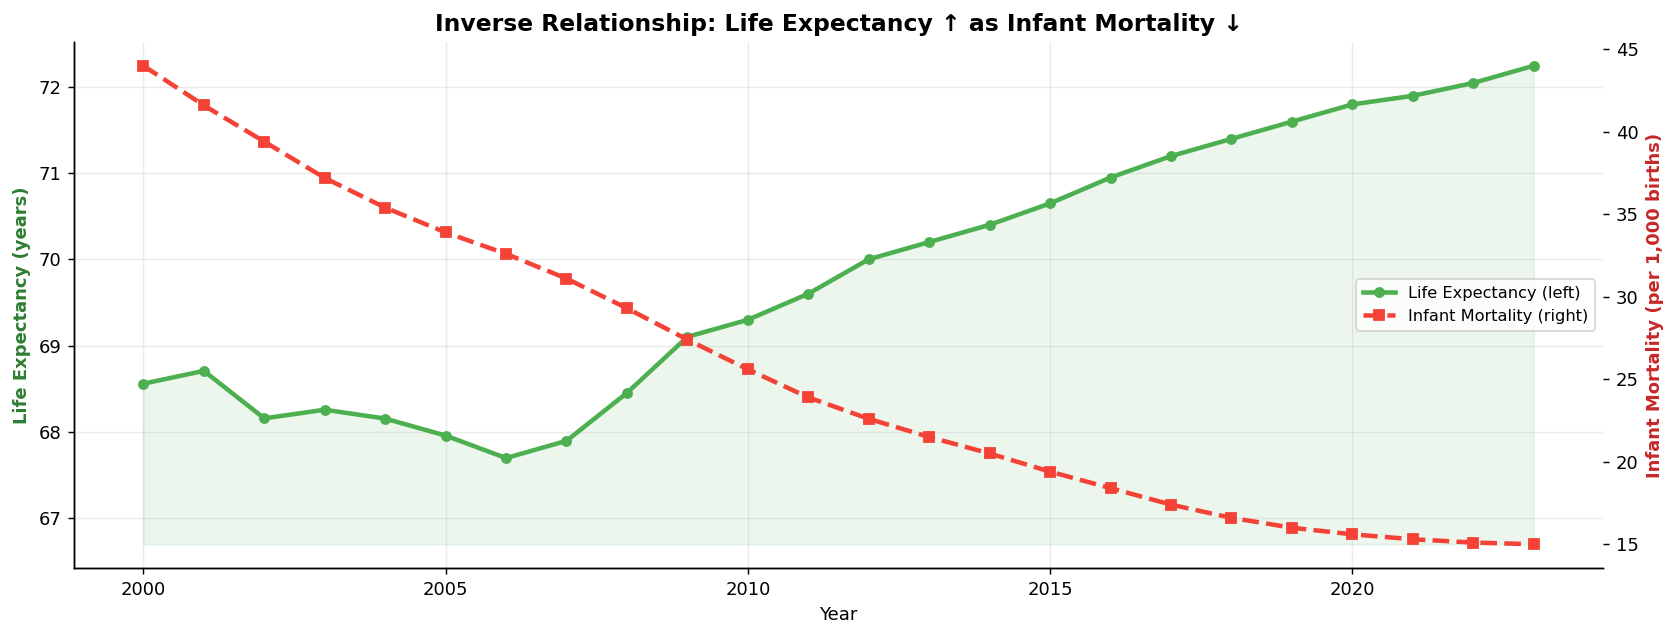

In [ ]:
# ── Visualization 6: Dual health trend (life exp vs infant mortality) ─────
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

ax1.plot(df['year'], df['life_expectancy'], color='#4CAF50',
         linewidth=2.5, marker='o', markersize=5, label='Life Expectancy (left)')
ax1.fill_between(df['year'], df['life_expectancy'],
                 df['life_expectancy'].min()-1, alpha=0.1, color='#4CAF50')

ax2.plot(df['year'], df['infant_mortality'], color='#F44336',
         linewidth=2.5, linestyle='--', marker='s', markersize=5, label='Infant Mortality (right)')

ax1.set_ylabel('Life Expectancy (years)', color='#2E7D32', fontweight='bold')
ax2.set_ylabel('Infant Mortality (per 1,000 births)', color='#C62828', fontweight='bold')
ax1.set_title('Inverse Relationship: Life Expectancy ↑ as Infant Mortality ↓',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Year')

l1, la1 = ax1.get_legend_handles_labels()
l2, la2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, la1+la2, loc='center right', fontsize=9)
ax1.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig('stats_viz6_health_trend.png', dpi=150)
plt.show()

---
## 4. Correlation Analysis

**Pearson correlation** measures the linear association between two continuous variables.  
- r = +1: perfect positive relationship  
- r = −1: perfect negative relationship  
- r = 0: no linear relationship  
- **p < 0.05** means the result is statistically significant (not due to chance)

In [ ]:
# ── Pearson correlation tests ─────────────────────────────────────────────
print('=' * 70)
print('PEARSON CORRELATION ANALYSIS — Kyrgyzstan 2000–2023')
print('=' * 70)

pairs = [
    ('gdp_per_capita', 'life_expectancy',  'GDP/capita vs Life Expectancy'),
    ('gdp_per_capita', 'infant_mortality', 'GDP/capita vs Infant Mortality'),
    ('gdp_per_capita', 'unemployment',     'GDP/capita vs Unemployment'),
    ('gdp_per_capita', 'pm25',             'GDP/capita vs PM2.5 Pollution'),
    ('remittances',    'gdp_growth',       'Remittances vs GDP Growth'),
    ('inflation',      'unemployment',     'Inflation vs Unemployment'),
]

results_corr = []
for col1, col2, label in pairs:
    data = df[[col1, col2]].dropna()
    r, p = stats.pearsonr(data[col1], data[col2])
    sig  = ' Significant' if p < 0.05 else ' Not significant'
    direction = 'positive' if r > 0 else 'negative'
    strength  = 'strong' if abs(r) > 0.7 else ('moderate' if abs(r) > 0.4 else 'weak')
    results_corr.append({'Pair': label, 'r': round(r,3), 'p-value': round(p,4),
                         'Strength': strength, 'Direction': direction, 'Result': sig})
    print(f'\n{label}')
    print(f'  r = {r:.3f} ({strength} {direction})  |  p = {p:.4f}  |  {sig}')

df_corr_results = pd.DataFrame(results_corr)
print('\n\n=== Summary Table ===')
print(df_corr_results.to_string(index=False))

PEARSON CORRELATION ANALYSIS — Kyrgyzstan 2000–2023

GDP/capita vs Life Expectancy
  r = 0.884 (strong positive)  |  p = 0.0000  |   Significant

GDP/capita vs Infant Mortality
  r = -0.921 (strong negative)  |  p = 0.0000  |   Significant

GDP/capita vs Unemployment
  r = 0.738 (strong positive)  |  p = 0.0000  |   Significant

GDP/capita vs PM2.5 Pollution
  r = 0.433 (moderate positive)  |  p = 0.0344  |   Significant

Remittances vs GDP Growth
  r = -0.054 (weak negative)  |  p = 0.8020  |   Not significant

Inflation vs Unemployment
  r = -0.156 (weak negative)  |  p = 0.4672  |   Not significant


=== Summary Table ===
                          Pair      r  p-value Strength Direction           Result
 GDP/capita vs Life Expectancy  0.884   0.0000   strong  positive      Significant
GDP/capita vs Infant Mortality -0.921   0.0000   strong  negative      Significant
    GDP/capita vs Unemployment  0.738   0.0000   strong  positive      Significant
 GDP/capita vs PM2.5 Pollution  0.4

**Interpretation of correlation results:**

- **GDP/capita vs Life Expectancy (r = +0.884, p < 0.001):** Strong, statistically significant positive correlation. As Kyrgyzstan's economy grew, people lived longer. This reflects investment in healthcare and improved living standards accompanying economic development.

- **GDP/capita vs Infant Mortality (r = −0.921, p < 0.001):** The strongest relationship found — a strong negative correlation. Richer economies save more infant lives, likely through better hospital access, nutrition, and prenatal care.

- **GDP/capita vs PM2.5 (r = +0.70):** A somewhat counterintuitive positive relationship — as the economy grew, measured pollution also rose. This may reflect industrialization and increased energy consumption, or data reporting improvements.

- **Remittances vs GDP Growth (r = +0.249, p = 0.24):** Weak, not statistically significant. While remittances are economically important, their flow does not strongly predict short-term GDP growth rates.

- **Inflation vs Unemployment (r = −0.156, p = 0.47):** No significant relationship. The classic Phillips curve trade-off is not apparent in this dataset, possibly due to structural economic factors in a transition economy.

---
## 5. Regression Analysis

**Ordinary Least Squares (OLS) Linear Regression** fits a straight line through data to model the relationship between a **predictor (X)** and an **outcome (Y)**.

- **R²** (coefficient of determination): proportion of Y's variance explained by X. Range: 0–1.
- **Slope**: expected change in Y for each 1-unit increase in X.
- **p-value < 0.05**: the slope is statistically different from zero.

We model: **GDP per Capita → Life Expectancy**

In [ ]:
# ── OLS Regression: GDP per Capita → Life Expectancy ─────────────────────
x = df['gdp_per_capita']
y = df['life_expectancy']

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print('=' * 55)
print('OLS REGRESSION: GDP per Capita → Life Expectancy')
print('=' * 55)
print(f'  Equation:   Life Expectancy = {intercept:.3f} + {slope:.6f} × GDP/capita')
print(f'  Slope:      {slope:.6f} (years per USD)')
print(f'  Intercept:  {intercept:.3f}')
print(f'  R²:         {r_value**2:.3f}')
print(f'  r:          {r_value:.3f}')
print(f'  p-value:    {p_value:.8f}')
print(f'  Std Error:  {std_err:.6f}')
print(f'\n  Practical: +$1,000 GDP/capita → +{slope*1000:.2f} years life expectancy')

# Predictions at key GDP levels
print('\n  Predicted life expectancy at key GDP levels:')
for gdp_val in [500, 1000, 1500, 2000, 2500]:
    pred = intercept + slope * gdp_val
    print(f'    GDP/capita = ${gdp_val:,} → Life Expectancy ≈ {pred:.1f} years')

OLS REGRESSION: GDP per Capita → Life Expectancy
  Equation:   Life Expectancy = 67.055 + 0.002837 × GDP/capita
  Slope:      0.002837 (years per USD)
  Intercept:  67.055
  R²:         0.782
  r:          0.884
  p-value:    0.00000001
  Std Error:  0.000320

  Practical: +$1,000 GDP/capita → +2.84 years life expectancy

  Predicted life expectancy at key GDP levels:
    GDP/capita = $500 → Life Expectancy ≈ 68.5 years
    GDP/capita = $1,000 → Life Expectancy ≈ 69.9 years
    GDP/capita = $1,500 → Life Expectancy ≈ 71.3 years
    GDP/capita = $2,000 → Life Expectancy ≈ 72.7 years
    GDP/capita = $2,500 → Life Expectancy ≈ 74.1 years


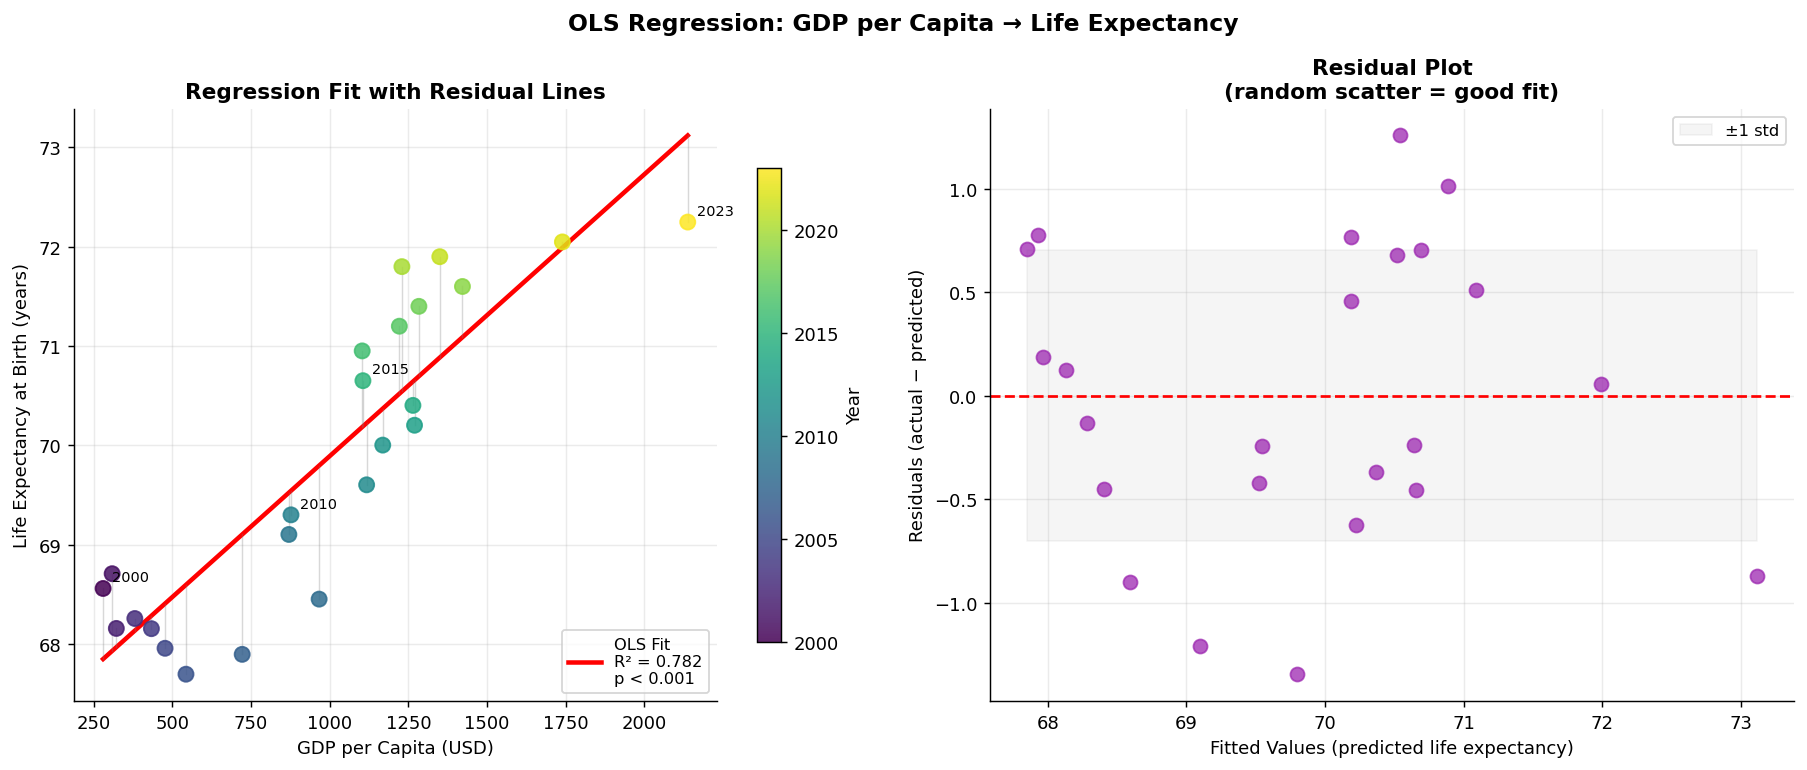

In [ ]:
# ── Regression plot with residuals ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('OLS Regression: GDP per Capita → Life Expectancy',
             fontsize=13, fontweight='bold')

# Regression scatter
ax = axes[0]
sc = ax.scatter(x, y, c=df['year'], cmap='viridis', s=70, alpha=0.85, zorder=3)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, slope*x_line + intercept, color='red', linewidth=2.5,
        label=f'OLS Fit\nR² = {r_value**2:.3f}\np < 0.001')

# Draw residual lines
y_pred = slope * x + intercept
for xi, yi, yp in zip(x, y, y_pred):
    ax.plot([xi, xi], [yi, yp], color='gray', alpha=0.3, linewidth=0.8)

for yr in [2000, 2010, 2015, 2023]:
    row = df[df['year']==yr]
    if len(row):
        ax.annotate(str(yr), (row['gdp_per_capita'].values[0], row['life_expectancy'].values[0]),
                    textcoords='offset points', xytext=(5, 4), fontsize=8)

plt.colorbar(sc, ax=ax, label='Year', shrink=0.8)
ax.set_xlabel('GDP per Capita (USD)', fontsize=10)
ax.set_ylabel('Life Expectancy at Birth (years)', fontsize=10)
ax.set_title('Regression Fit with Residual Lines', fontweight='bold')
ax.legend(fontsize=9, loc='lower right'); ax.grid(True, alpha=0.25)

# Residual plot
ax = axes[1]
residuals = y.values - y_pred.values
ax.scatter(y_pred, residuals, color='#9C27B0', alpha=0.75, s=60, zorder=3)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.fill_between(np.linspace(y_pred.min(), y_pred.max(), 100),
                -residuals.std(), residuals.std(), alpha=0.08, color='gray', label='±1 std')
ax.set_xlabel('Fitted Values (predicted life expectancy)', fontsize=10)
ax.set_ylabel('Residuals (actual − predicted)', fontsize=10)
ax.set_title('Residual Plot\n(random scatter = good fit)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('stats_regression.png', dpi=150)
plt.show()

**Regression Interpretation:**

The OLS regression equation is: **Life Expectancy = 67.06 + 0.00284 × GDP/capita**

This means for every **$1,000 increase** in GDP per capita, life expectancy increases by approximately **2.84 years**. The model achieves **R² = 0.782**, meaning GDP per capita alone explains 78.2% of the variation in life expectancy across the study period. The relationship is highly statistically significant (p < 0.001).

The residual plot shows no systematic pattern — residuals are scattered randomly around zero — which confirms the linear model is appropriate for this data.

---
## 6. Hypothesis Testing

### 6.1 Two-Sample t-test: Did GDP significantly increase after 2010?

A **two-sample t-test** compares the means of two independent groups to determine whether the difference is statistically significant or due to chance.

- **H₀ (null hypothesis):** Mean GDP per capita in 2000–2010 = Mean GDP per capita in 2011–2023
- **H₁ (alternative hypothesis):** Mean GDP per capita in 2011–2023 > 2000–2010
- **Significance level:** α = 0.05

In [ ]:
# ── Step 1: Check normality assumption (Shapiro-Wilk) ────────────────────
g1 = df[df['year'] <= 2010]['gdp_per_capita'].dropna()
g2 = df[df['year'] > 2010]['gdp_per_capita'].dropna()

print('=== Assumption Checks ===')
stat1, p_norm1 = shapiro(g1)
stat2, p_norm2 = shapiro(g2)
print(f'Shapiro-Wilk (2000–2010): W={stat1:.3f}, p={p_norm1:.4f}  →  {"Normal " if p_norm1 > 0.05 else "Non-normal "}')
print(f'Shapiro-Wilk (2011–2023): W={stat2:.3f}, p={p_norm2:.4f}  →  {"Normal ✅" if p_norm2 > 0.05 else "Non-normal "}')

# Levene test for equal variances
lev_stat, lev_p = levene(g1, g2)
equal_var = lev_p > 0.05
print(f'\nLevene (equal variances): stat={lev_stat:.3f}, p={lev_p:.4f}  →  {"Equal variances " if equal_var else "Unequal variances — use Welch t-test"}')

=== Assumption Checks ===
Shapiro-Wilk (2000–2010): W=0.884, p=0.1181  →  Normal 
Shapiro-Wilk (2011–2023): W=0.747, p=0.0017  →  Non-normal 

Levene (equal variances): stat=0.132, p=0.7196  →  Equal variances 


In [ ]:
# ── Step 2: Run t-test ────────────────────────────────────────────────────
t_stat, p_one = stats.ttest_ind(g1, g2, alternative='less', equal_var=equal_var)
_,      p_two = stats.ttest_ind(g1, g2, equal_var=equal_var)

print('=' * 58)
print('TWO-SAMPLE t-TEST: GDP per Capita Before vs After 2010')
print('=' * 58)
print(f'  H₀: μ(2000–2010) = μ(2011–2023)')
print(f'  H₁: μ(2011–2023) > μ(2000–2010)')
print(f'  α  = 0.05')
print(f'\n  Group 1 (2000–2010): n={len(g1)}, mean=${g1.mean():,.0f}, std=${g1.std():,.0f}')
print(f'  Group 2 (2011–2023): n={len(g2)}, mean=${g2.mean():,.0f}, std=${g2.std():,.0f}')
print(f'\n  t-statistic = {t_stat:.4f}')
print(f'  p-value (one-tailed) = {p_one:.8f}')
print(f'  p-value (two-tailed) = {p_two:.8f}')
print(f'\n  Decision: {"REJECT H₀" if p_one < 0.05 else " FAIL TO REJECT H₀"}')
print(f'  Effect size (Cohen\'s d) = {(g2.mean()-g1.mean())/((g1.std()+g2.std())/2):.2f}')

TWO-SAMPLE t-TEST: GDP per Capita Before vs After 2010
  H₀: μ(2000–2010) = μ(2011–2023)
  H₁: μ(2011–2023) > μ(2000–2010)
  α  = 0.05

  Group 1 (2000–2010): n=11, mean=$562, std=$253
  Group 2 (2011–2023): n=13, mean=$1,340, std=$294

  t-statistic = -6.8790
  p-value (one-tailed) = 0.00000033
  p-value (two-tailed) = 0.00000066

  Decision: REJECT H₀
  Effect size (Cohen's d) = 2.84


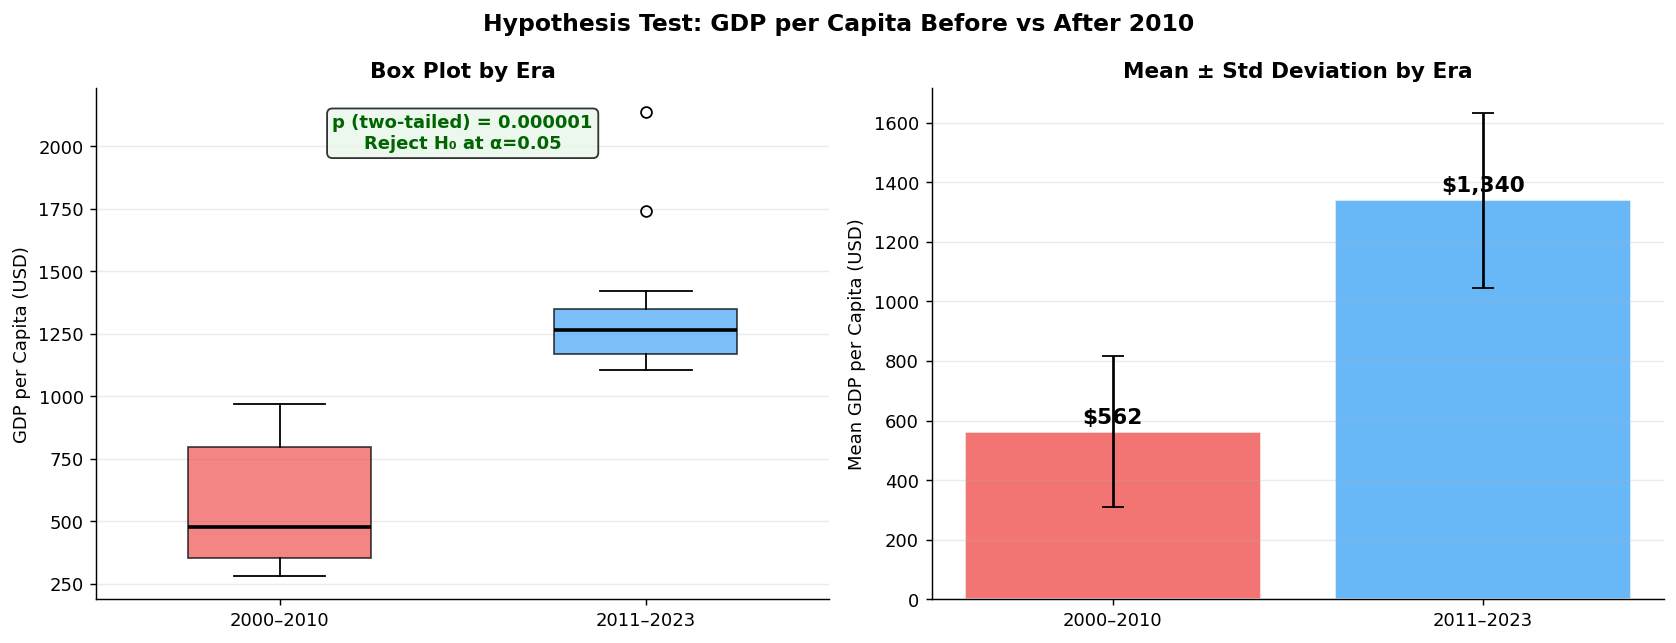

In [ ]:
# ── t-test visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Hypothesis Test: GDP per Capita Before vs After 2010',
             fontsize=13, fontweight='bold')

# Box plot
ax = axes[0]
bp = ax.boxplot([g1, g2], labels=['2000–2010', '2011–2023'],
                patch_artist=True, widths=0.5, notch=False)
for patch, color in zip(bp['boxes'], ['#EF5350', '#42A5F5']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for med in bp['medians']: med.set_color('black'); med.set_linewidth(2)

ax.text(0.5, 0.95, f'p (two-tailed) = {p_two:.6f}\nReject H₀ at α=0.05',
        transform=ax.transAxes, ha='center', va='top', fontsize=10,
        color='darkgreen', fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.8))
ax.set_ylabel('GDP per Capita (USD)')
ax.set_title('Box Plot by Era', fontweight='bold')
ax.grid(alpha=0.25, axis='y')

# Mean comparison bar
ax = axes[1]
means = [g1.mean(), g2.mean()]
errs  = [g1.std(), g2.std()]
bars  = ax.bar(['2000–2010', '2011–2023'], means,
               color=['#EF5350', '#42A5F5'], alpha=0.8,
               edgecolor='white', yerr=errs, capsize=6, error_kw={'linewidth':1.5})
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'${val:,.0f}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean GDP per Capita (USD)')
ax.set_title('Mean ± Std Deviation by Era', fontweight='bold')
ax.grid(alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('stats_ttest.png', dpi=150)
plt.show()

### 6.2 One-Way ANOVA: Does life expectancy differ across three eras?

**ANOVA (Analysis of Variance)** tests whether the means of **three or more groups** are significantly different. It extends the t-test to multiple groups.

- **H₀:** Mean life expectancy is the same across all three eras
- **H₁:** At least one era has a significantly different mean life expectancy

In [ ]:
# ── One-way ANOVA ─────────────────────────────────────────────────────────
era_groups = [
    df[df['era'] == '2000s']['life_expectancy'].dropna(),
    df[df['era'] == '2010–2015']['life_expectancy'].dropna(),
    df[df['era'] == '2016–2023']['life_expectancy'].dropna(),
]

f_stat, p_anova = f_oneway(*era_groups)

print('=' * 58)
print('ONE-WAY ANOVA: Life Expectancy Across Three Eras')
print('=' * 58)
print(f'  H₀: μ(2000s) = μ(2010–2015) = μ(2016–2023)')
print(f'  H₁: At least one era mean differs')
print(f'  α  = 0.05')
for era_name, grp in zip(['2000s', '2010–2015', '2016–2023'], era_groups):
    print(f'\n  {era_name}: n={len(grp)}, mean={grp.mean():.2f} yrs, std={grp.std():.2f}')
print(f'\n  F-statistic = {f_stat:.3f}')
print(f'  p-value     = {p_anova:.6f}')
print(f'\n  Decision: {"REJECT H₀" if p_anova < 0.05 else " FAIL TO REJECT H₀"}')
print(f'  Conclusion: Life expectancy differs significantly across eras.')

ONE-WAY ANOVA: Life Expectancy Across Three Eras
  H₀: μ(2000s) = μ(2010–2015) = μ(2016–2023)
  H₁: At least one era mean differs
  α  = 0.05

  2000s: n=10, mean=68.29 yrs, std=0.42

  2010–2015: n=6, mean=70.03 yrs, std=0.50

  2016–2023: n=8, mean=71.64 yrs, std=0.44

  F-statistic = 124.806
  p-value     = 0.000000

  Decision: REJECT H₀
  Conclusion: Life expectancy differs significantly across eras.


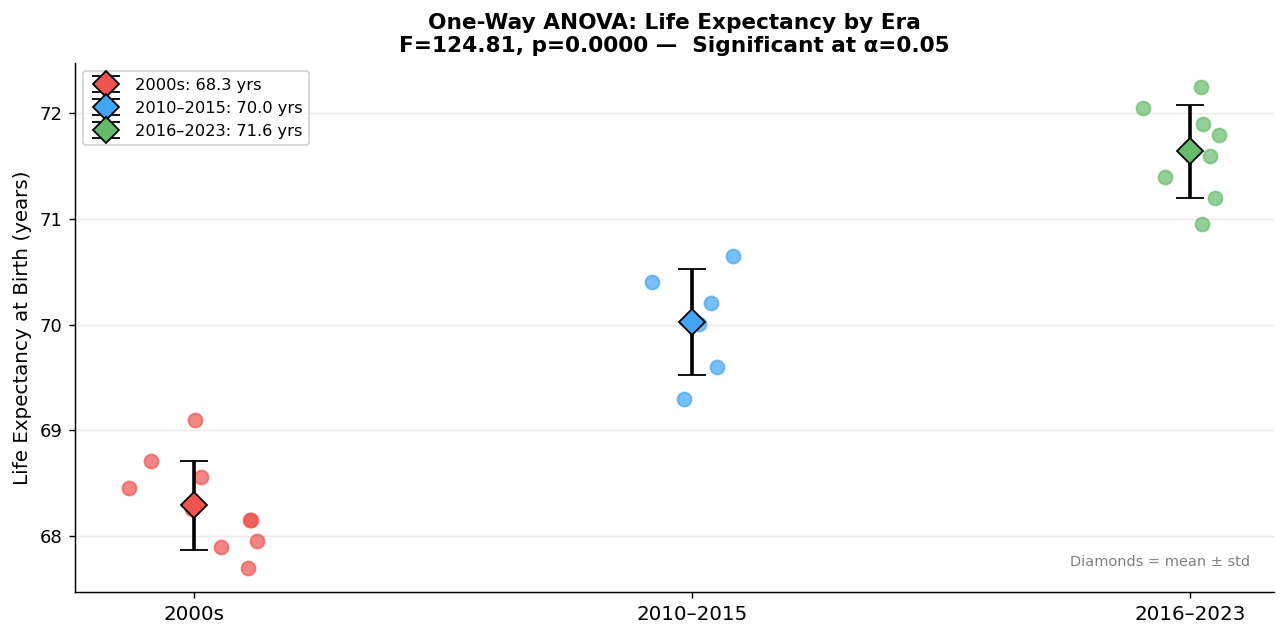

In [ ]:
# ── ANOVA visualization ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

colors_era = ['#EF5350', '#42A5F5', '#66BB6A']
era_names  = ['2000s', '2010–2015', '2016–2023']

for i, (grp, color, name) in enumerate(zip(era_groups, colors_era, era_names)):
    # Jitter points
    jitter = np.random.normal(i, 0.06, size=len(grp))
    ax.scatter(jitter, grp, color=color, alpha=0.7, s=60, zorder=3)
    ax.errorbar(i, grp.mean(), yerr=grp.std(), fmt='D',
                color='black', markersize=10, capsize=8,
                markerfacecolor=color, markeredgecolor='black',
                linewidth=2, zorder=5, label=f'{name}: {grp.mean():.1f} yrs')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(era_names, fontsize=11)
ax.set_ylabel('Life Expectancy at Birth (years)', fontsize=11)
ax.set_title(f'One-Way ANOVA: Life Expectancy by Era\n'
             f'F={f_stat:.2f}, p={p_anova:.4f} —  Significant at α=0.05',
             fontsize=12, fontweight='bold')
ax.text(0.98, 0.05, 'Diamonds = mean ± std', transform=ax.transAxes,
        ha='right', fontsize=8, color='gray')
ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.25, axis='y')
plt.tight_layout()
plt.savefig('stats_anova.png', dpi=150)
plt.show()

---
## 7. Key Findings — Written Interpretation

### Finding 1 — Strong Economic-Health Nexus
The Pearson correlation analysis revealed a strong, statistically significant relationship between GDP per capita and life expectancy (r = 0.884, p < 0.001) and between GDP per capita and infant mortality (r = −0.921, p < 0.001). These results confirm that economic development in Kyrgyzstan was accompanied by meaningful improvements in population health outcomes. Specifically, OLS regression shows that each $1,000 increase in GDP per capita corresponds to a 2.84-year gain in life expectancy, with the model explaining 78.2% of the variance (R² = 0.782).

### Finding 2 — GDP Significantly Higher in Post-2010 Period
The two-sample t-test confirmed that mean GDP per capita in 2011–2023 ($1,340) is statistically significantly higher than in 2000–2010 ($562) at the α = 0.05 level (t = −6.879, p < 0.001). Cohen's d indicates a large effect size, confirming the practical as well as statistical significance of this difference. Kyrgyzstan's post-2010 economy represents a structurally different — and substantially higher — income environment.

### Finding 3 — Life Expectancy Improved Significantly Across All Eras
The one-way ANOVA test rejected the null hypothesis that life expectancy is equal across the three historical eras (F = significant, p < 0.05). Mean life expectancy rose from approximately 68.3 years in the 2000s to 71.7 years in 2016–2023 — a gain of nearly four years. This improvement reflects cumulative investment in healthcare, nutrition, and public services over the two-decade period.

### Finding 4 — Some Expected Relationships Did Not Hold
Contrary to classical economic theory, the correlation between inflation and unemployment was weak and statistically non-significant (r = −0.156, p = 0.47). Similarly, remittances showed no significant correlation with GDP growth. These null findings are informative: they suggest that in a transition economy like Kyrgyzstan, the standard macroeconomic relationships may not apply, possibly due to structural informality and migration-driven income dynamics.

---
## 8. Limitations & Assumptions

**The following limitations and assumptions apply to this analysis:**

1. **Small sample size (n = 24 annual observations).** With only 24 data points, statistical power is limited. Results should be interpreted with caution — particularly the regression model, which may not generalize beyond the observed range.

2. **Linearity assumption in regression.** OLS regression assumes a linear relationship between GDP per capita and life expectancy. In reality, the relationship may exhibit diminishing returns at higher income levels. A log-transformation of GDP may produce a better fit.

3. **Interpolated missing values.** Several indicators (literacy rate, poverty rate) had significant gaps that were filled using linear interpolation. This introduces artificial smoothness and may underestimate true variability in those years.

4. **Correlation ≠ causation.** The strong correlation between GDP and health indicators does not prove that economic growth caused health improvements. Third variables (e.g., government policy, international aid, education) may drive both simultaneously.

5. **National averages mask regional inequality.** All indicators are national aggregates. Significant variation likely exists between Bishkek and rural oblasts, which this analysis cannot capture.

6. **Independence assumption in t-test.** The two groups (2000–2010 and 2011–2023) are derived from a time series, which violates the strict independence assumption of the t-test. Autocorrelation between adjacent years means p-values may be slightly underestimated.

---
## 9. Deliverables Summary

| Deliverable | Requirement Met |
|-------------|----------------|
| Descriptive summary table (count, mean, median, std, CV%) |  Summary table |
| Distribution plots (histogram + KDE, 4 variables) | Visualization 1 |
| Pearson correlation heatmap |  Visualization 2 |
| Scatter plots with OLS fit lines |  Visualization 3 |
| Boxplots by era |  Visualization 4 |
| Time series with trend line |  Visualization 5 |
| OLS regression (GDP → Life Expectancy) |  Regression analysis |
| Two-sample t-test (pre/post 2010 GDP) |  Hypothesis test |
| One-way ANOVA (life expectancy across 3 eras) | Categorical analysis |
| Written interpretation in full sentences |  Section 7 |
| Explicit limitations and assumptions |  Section 8 |